In [1]:
DATA_PATH = "placement_predict_50k_adjusted (1).csv"
TARGET_COL = "PlacementStatus"

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab/placement_predict_50k_adjusted.csv')
print(df.head())
print(df.columns)

   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkillsRating  \
0               1             0             

In [4]:
print(df.columns)

Index(['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel',
       'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus',
       'IsAnomaly'],
      dtype='object')


In [5]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [6]:
TARGET_COL = "PlacementStatus"

In [7]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7897


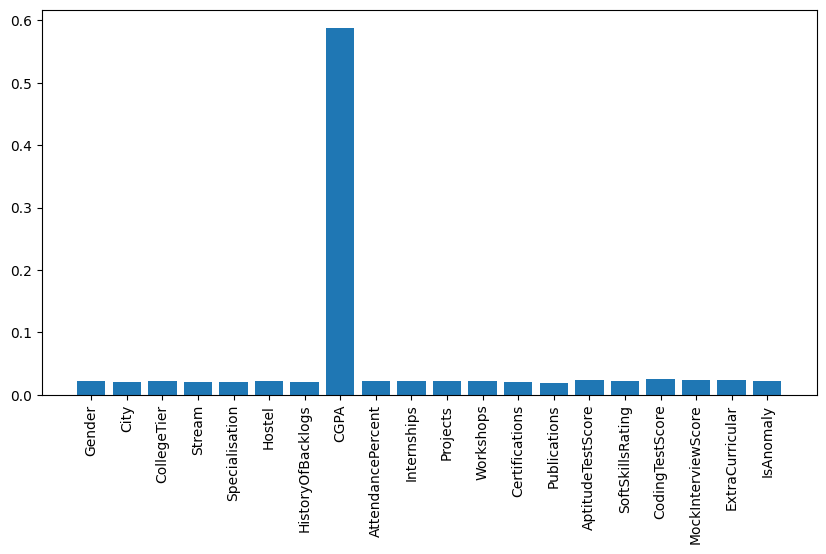

In [11]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.show()


In [13]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.7897


In [14]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.7897


In [15]:
%whos

Variable           Type             Data/Info
---------------------------------------------
DATA_PATH          str              placement_predict_50k_adjusted (1).csv
LabelEncoder       type             <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
TARGET_COL         str              PlacementStatus
X                  DataFrame               Gender  City  Coll<...>[50000 rows x 20 columns]
XGBClassifier      type             <class 'xgboost.sklearn.XGBClassifier'>
X_test             DataFrame               Gender  City  Coll<...>[10000 rows x 20 columns]
X_train            DataFrame               Gender  City  Coll<...>[40000 rows x 20 columns]
accuracy_score     function         <function accuracy_score at 0x7ef1834431a0>
col                str              IsAnomaly
df                 DataFrame               Gender  City  Coll<...>[50000 rows x 21 columns]
drive              module           <module 'google.colab.dri<...>s/google/colab/drive.py'>
importance         ndarray 

In [16]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 19015, number of negative: 20985
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1597
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475375 -> initscore=-0.098580
[LightGBM] [Info] Start training from score -0.098580


In [17]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print("LightGBM Accuracy:", accuracy_score(y_test, pred_lgbm))

XGBoost Accuracy: 0.7897
LightGBM Accuracy: 0.7955


In [18]:
%whos

Variable           Type              Data/Info
----------------------------------------------
DATA_PATH          str               placement_predict_50k_adjusted (1).csv
LGBMClassifier     type              <class 'lightgbm.sklearn.LGBMClassifier'>
LabelEncoder       type              <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
TARGET_COL         str               PlacementStatus
X                  DataFrame                Gender  City  Coll<...>[50000 rows x 20 columns]
XGBClassifier      type              <class 'xgboost.sklearn.XGBClassifier'>
X_test             DataFrame                Gender  City  Coll<...>[10000 rows x 20 columns]
X_train            DataFrame                Gender  City  Coll<...>[40000 rows x 20 columns]
accuracy_score     function          <function accuracy_score at 0x7ef1834431a0>
col                str               IsAnomaly
df                 DataFrame                Gender  City  Coll<...>[50000 rows x 21 columns]
drive              module   

In [19]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print("LightGBM Accuracy:", accuracy_score(y_test, pred_lgbm))

XGBoost Accuracy: 0.7897
LightGBM Accuracy: 0.7955


In [20]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[4218 1048]
 [1055 3679]]


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      5266
           1       0.78      0.78      0.78      4734

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

